In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    r2_score,
    mean_squared_error,
    mean_absolute_error
)
from scipy.stats import pearsonr, spearmanr


c:\Users\psadi\anaconda3\envs\ds6050\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# -----------------------------
# 1. Load data
# -----------------------------
try:
    df = pd.read_csv("ml_panel_noaa_x_fda_recalls_x_cost.csv")
except FileNotFoundError:
    df = pd.read_csv("ml_panel_noaa_x_fda_recalls_x_cost(1).csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["state_abbr", "date"]).reset_index(drop=True)

target = "log_pathogen_cost_index"
raw_target = "pathogen_weighted_cost_index"

# Event indicator
df["event_flag"] = (df[raw_target] > 0).astype(int)

# -----------------------------
# 2. Feature engineering
# -----------------------------
# Month / seasonality
df["month"] = df["date"].dt.month
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Rolling climate baselines by state
df["temp_roll12"] = df.groupby("state_abbr")["temp_f"].transform(
    lambda x: x.rolling(12, min_periods=3).mean()
)
df["pcpn_roll12"] = df.groupby("state_abbr")["pcpn_in"].transform(
    lambda x: x.rolling(12, min_periods=3).mean()
)

# Climate anomalies
df["temp_dev"] = df["temp_f"] - df["temp_roll12"]
df["pcpn_dev"] = df["pcpn_in"] - df["pcpn_roll12"]

# Interactions
df["temp_x_pcpn"] = df["temp_f"] * df["pcpn_in"]
df["temp_dev_x_pcpn_dev"] = df["temp_dev"] * df["pcpn_dev"]

# Event memory features
df["event_lag1"] = df.groupby("state_abbr")["event_flag"].shift(1)
df["event_roll3"] = (
    df.groupby("state_abbr")["event_flag"]
      .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# Optional anomaly interaction
if "temp_anom" in df.columns and "pcpn_anom" in df.columns:
    df["temp_anom_x_pcpn_anom"] = df["temp_anom"] * df["pcpn_anom"]

# -----------------------------
# 3. Train/test split
# -----------------------------
train_df = df[df["year"].between(2012, 2024)].copy()
test_df  = df[df["year"] >= 2025].copy()

# -----------------------------
# 4. Train-only state features
# -----------------------------
state_baseline = train_df.groupby("state_abbr")[target].mean()
global_baseline = train_df[target].mean()

train_df["state_baseline_cost"] = train_df["state_abbr"].map(state_baseline).fillna(global_baseline)
test_df["state_baseline_cost"]  = test_df["state_abbr"].map(state_baseline).fillna(global_baseline)

state_event_rate = train_df.groupby("state_abbr")["event_flag"].mean()
global_event_rate = train_df["event_flag"].mean()

train_df["state_event_rate"] = train_df["state_abbr"].map(state_event_rate).fillna(global_event_rate)
test_df["state_event_rate"]  = test_df["state_abbr"].map(state_event_rate).fillna(global_event_rate)

# Fill remaining NaNs from lags/rolls
train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

# -----------------------------
# 5. Features for full classifier
# -----------------------------
drop_cols = [
    target,
    raw_target,
    "date",
    "year",
    "state_abbr",
    "recall_count",
    "pathogen_recalls",
    "class_I",
    "class_II",
    "class_III",
    "event_flag"
]

feature_cols = [c for c in train_df.columns if c not in drop_cols]

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

y_train_cls = train_df["event_flag"]
y_test_cls = test_df["event_flag"]

# -----------------------------
# 6. Full classifier
# -----------------------------
pos = y_train_cls.sum()
neg = len(y_train_cls) - pos
scale_pos_weight = neg / pos if pos > 0 else 1.0

clf = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cuda",
    random_state=123,
    scale_pos_weight=scale_pos_weight
)

clf_param_grid = {
    "n_estimators": [300, 500, 800, 1200],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.1, 1.0],
    "reg_lambda": [1, 5, 10]
}

tscv = TimeSeriesSplit(n_splits=6)

clf_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=clf_param_grid,
    n_iter=30,
    scoring="average_precision",
    cv=tscv,
    verbose=1,
    n_jobs=1,
    random_state=123,
    error_score="raise"
)

clf_search.fit(X_train, y_train_cls)
best_clf = clf_search.best_estimator_
train_event_prob = best_clf.predict_proba(X_train)[:, 1]
test_event_prob = best_clf.predict_proba(X_test)[:, 1]

full_auc = roc_auc_score(y_test_cls, test_event_prob)
full_ap = average_precision_score(y_test_cls, test_event_prob)

print("Best full classifier params:")
print(clf_search.best_params_)
print("\nFull classifier")
print("Feature count:", len(feature_cols))
print("Train event rate:", y_train_cls.mean())
print("Test event rate:", y_test_cls.mean())
print("Test ROC AUC:", full_auc)
print("Test Average Precision:", full_ap)


Fitting 6 folds for each of 30 candidates, totalling 180 fits


c:\Users\psadi\anaconda3\envs\ds6050\Lib\site-packages\xgboost\core.py:751: UserWarning: [15:04:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Best full classifier params:
{'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 800, 'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.8}

Full classifier
Feature count: 22
Train event rate: 0.11561274756207902
Test event rate: 0.06717687074829932
Test ROC AUC: 0.9853339948997841
Test Average Precision: 0.8279490862012323


In [4]:
# -----------------------------
# 6. Reduce to top 10 features and retrain
# -----------------------------
importances = pd.Series(best_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)

top_features = importances.head(10).index.tolist()
print("Top 10 features used for retraining:")
print(top_features)

X_train_small = X_train[top_features]
X_test_small = X_test[top_features]

clf_small = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cuda",
    random_state=123,
    scale_pos_weight=scale_pos_weight,
    **clf_search.best_params_
)

clf_small.fit(X_train_small, y_train_cls)
test_event_prob_small = clf_small.predict_proba(X_test_small)[:, 1]

auc_small = roc_auc_score(y_test_cls, test_event_prob_small)
ap_small = average_precision_score(y_test_cls, test_event_prob_small)

print("===== Top-10 Feature Model Performance =====")
print("ROC AUC:", auc_small)
print("Average Precision:", ap_small)

print("===== Comparison =====")
print("Full model AUC:", full_auc)
print("Top-10 model AUC:", auc_small)
print("Full model AP:", full_ap)
print("Top-10 model AP:", ap_small)

Top 10 features used for retraining:
['event_roll3', 'state_event_rate', 'state_baseline_cost', 'event_lag1', 'temp_roll12', 'temp_f_roll3', 'month_sin', 'month', 'temp_f_lag1', 'temp_dev']
===== Top-10 Feature Model Performance =====
ROC AUC: 0.9889456861636454
Average Precision: 0.8575000386912609
===== Comparison =====
Full model AUC: 0.9853339948997841
Top-10 model AUC: 0.9889456861636454
Full model AP: 0.8279490862012323
Top-10 model AP: 0.8575000386912609



===== Full-feature classifier visuals =====


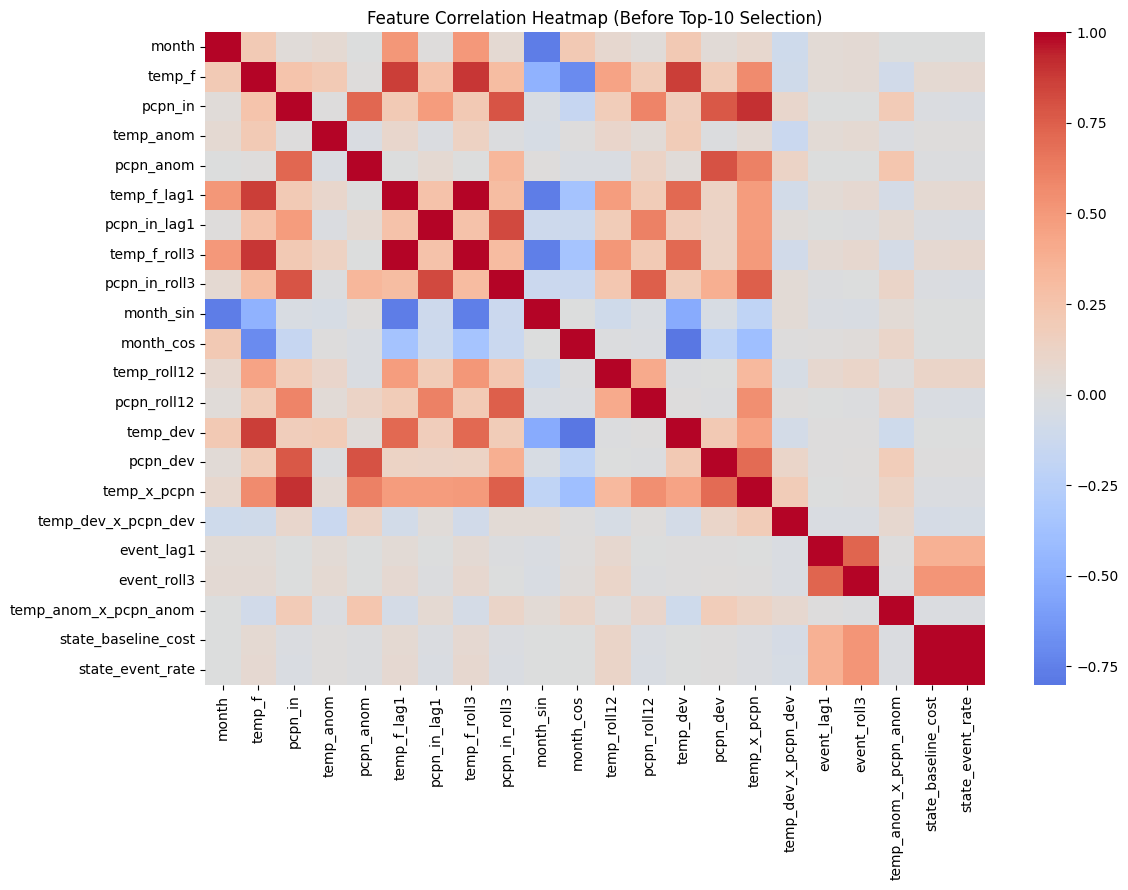

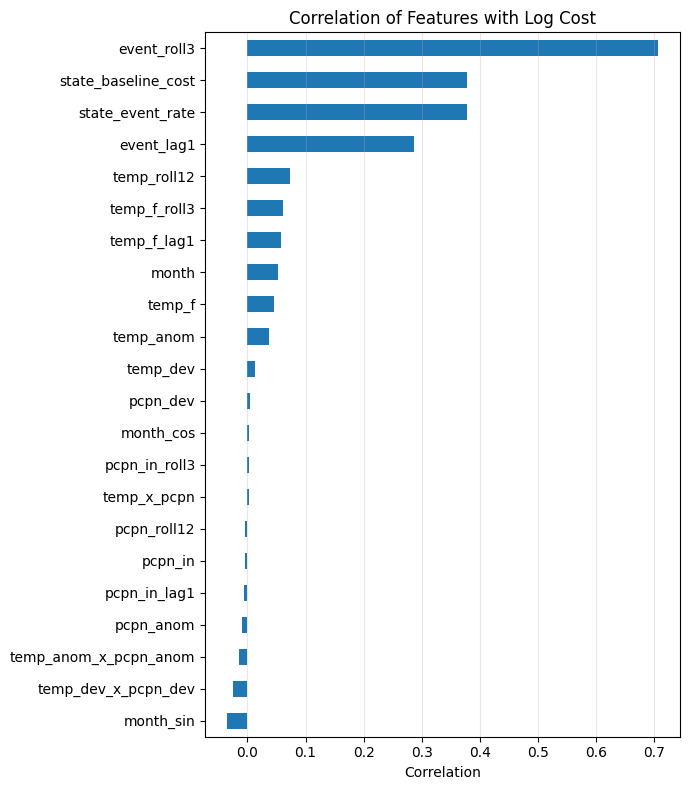

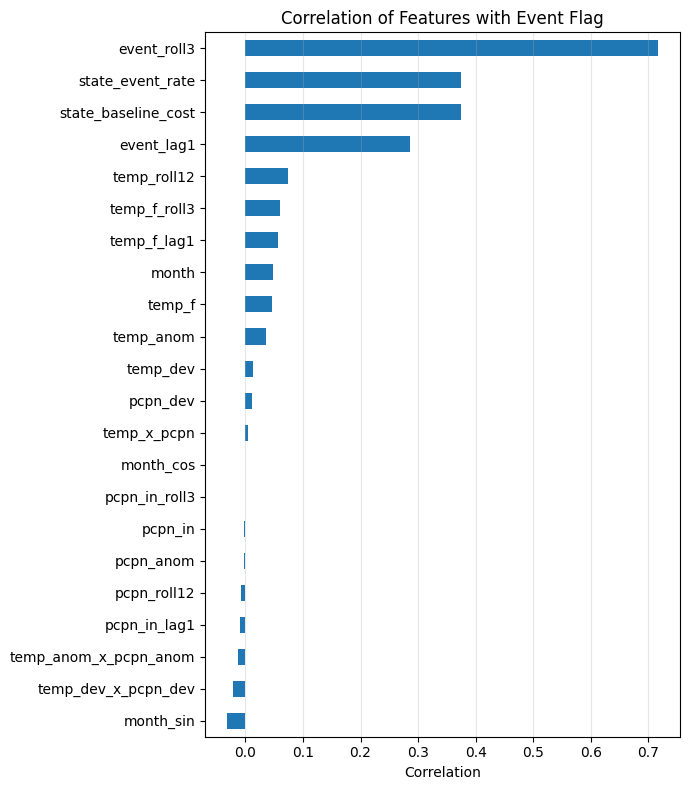

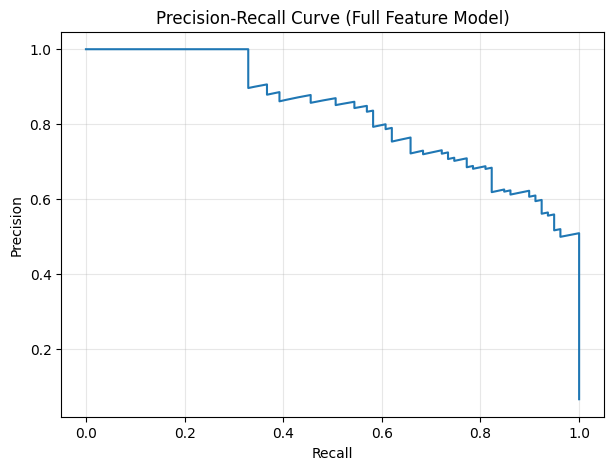

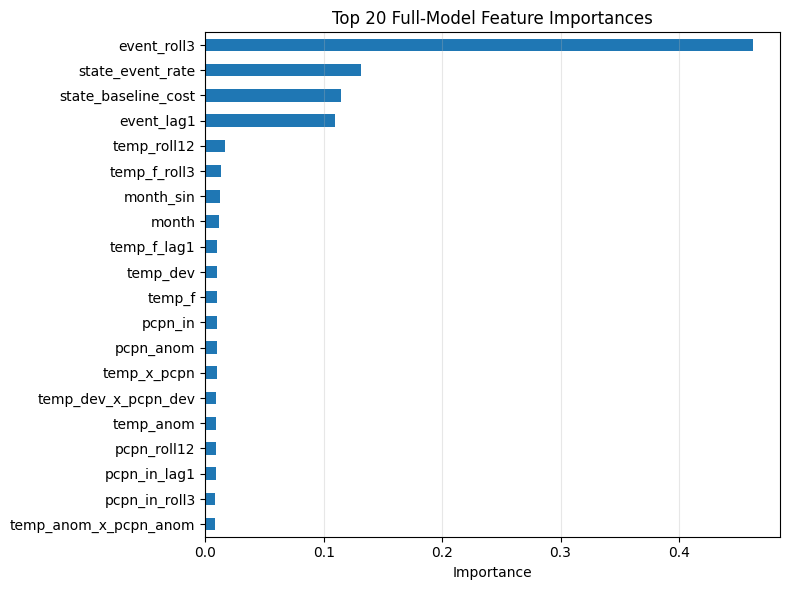


Top full-model features:
event_roll3              0.462196
state_event_rate         0.131339
state_baseline_cost      0.114798
event_lag1               0.109657
temp_roll12              0.016655
temp_f_roll3             0.013709
month_sin                0.012183
month                    0.011622
temp_f_lag1              0.010156
temp_dev                 0.010137
temp_f                   0.009915
pcpn_in                  0.009849
pcpn_anom                0.009773
temp_x_pcpn              0.009722
temp_dev_x_pcpn_dev      0.009252
temp_anom                0.009130
pcpn_roll12              0.009112
pcpn_in_lag1             0.009015
pcpn_in_roll3            0.008270
temp_anom_x_pcpn_anom    0.007993
dtype: float32

Top 10 features used for retraining:
['event_roll3', 'state_event_rate', 'state_baseline_cost', 'event_lag1', 'temp_roll12', 'temp_f_roll3', 'month_sin', 'month', 'temp_f_lag1', 'temp_dev']

===== Top-10 classifier performance =====
Top-10 model ROC AUC: 0.9889456861636454
Top-

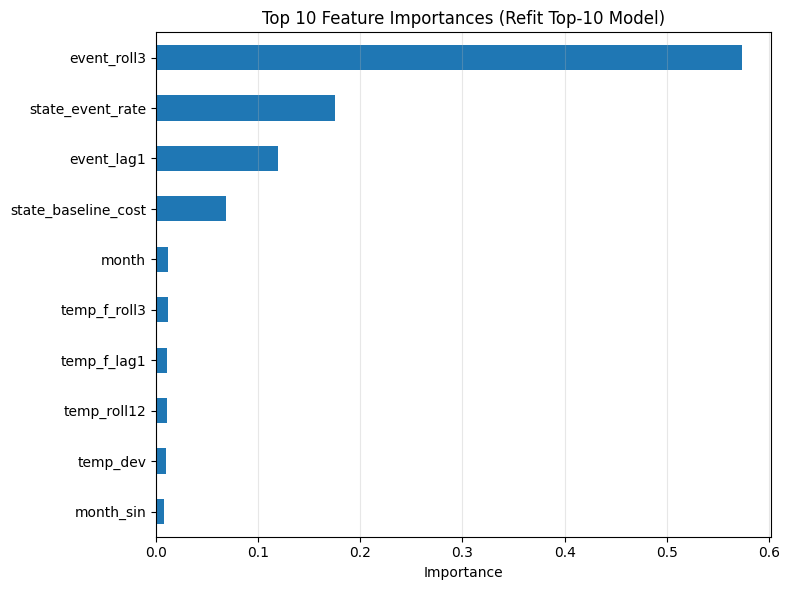

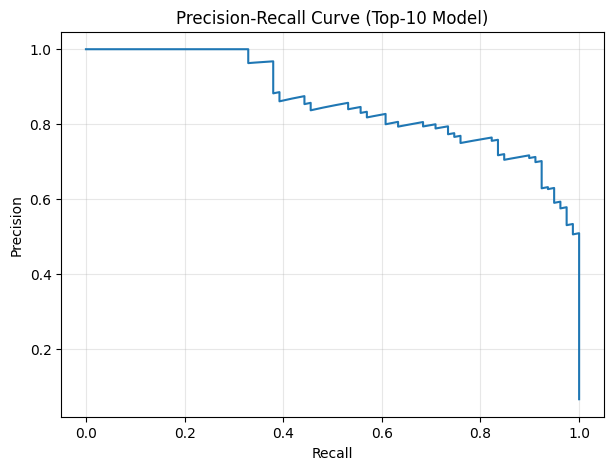

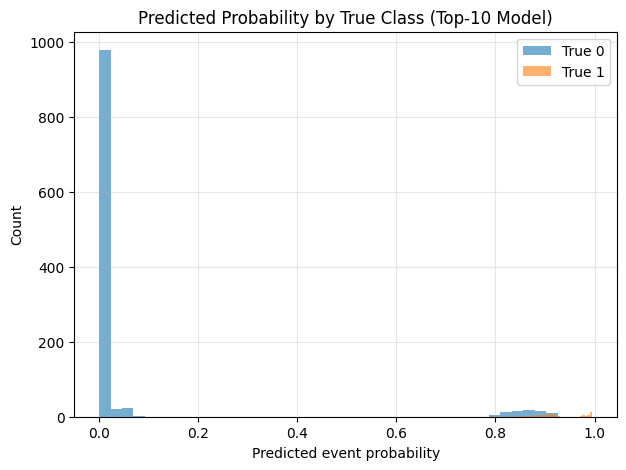

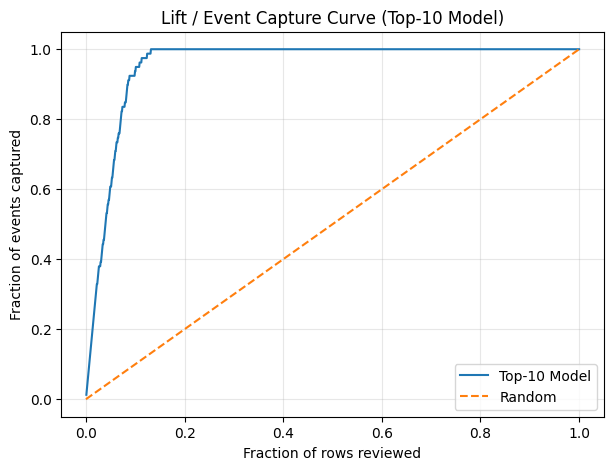

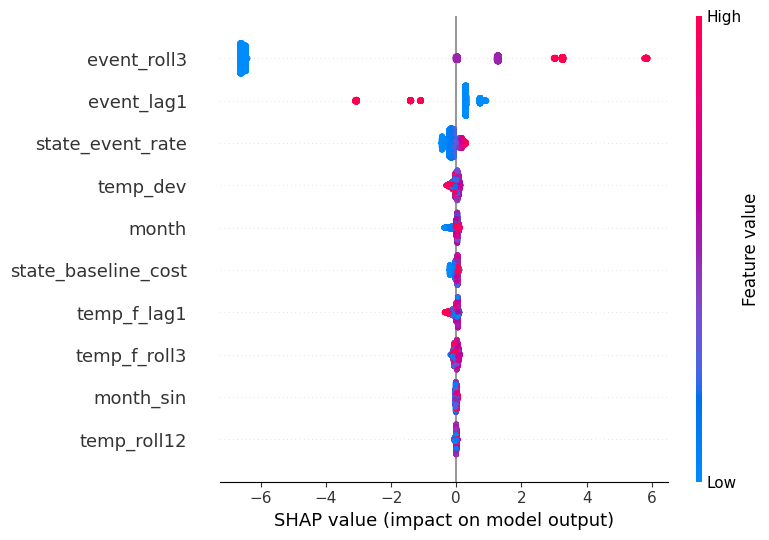

In [3]:
# -----------------------------
# Full-feature classifier visuals + correlation review
# -----------------------------
print("\n===== Full-feature classifier visuals =====")

# 1. Correlation heatmap across candidate predictors
plt.figure(figsize=(12, 9))
corr_full = train_df[feature_cols].corr()
sns.heatmap(corr_full, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap (Before Top-10 Selection)")
plt.tight_layout()
plt.show()

# 2. Correlation with target and event flag
corr_with_cost = train_df[feature_cols + [target]].corr()[target].sort_values()
corr_with_event = train_df[feature_cols + ["event_flag"]].corr()["event_flag"].sort_values()

plt.figure(figsize=(7, 8))
corr_with_cost.drop(target).plot(kind="barh")
plt.title("Correlation of Features with Log Cost")
plt.xlabel("Correlation")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 8))
corr_with_event.drop("event_flag").plot(kind="barh")
plt.title("Correlation of Features with Event Flag")
plt.xlabel("Correlation")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Precision-recall curve for full model
precision_full, recall_full, thresholds_full = precision_recall_curve(y_test_cls, test_event_prob)
plt.figure(figsize=(7, 5))
plt.plot(recall_full, precision_full)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Full Feature Model)")
plt.grid(True, alpha=0.3)
plt.show()

# 4. Full-model feature importance
importances_full = pd.Series(best_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
importances_full.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Full-Model Feature Importances")
plt.xlabel("Importance")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop full-model features:")
print(importances_full.head(20))

# -----------------------------
# Select top 10 features and refit
# -----------------------------
top_features = importances_full.head(10).index.tolist()
print("\nTop 10 features used for retraining:")
print(top_features)

X_train_top10 = X_train[top_features]
X_test_top10 = X_test[top_features]

clf_top10 = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cuda",
    random_state=123,
    scale_pos_weight=scale_pos_weight,
    **clf_search.best_params_
)

clf_top10.fit(X_train_top10, y_train_cls)
test_event_prob_top10 = clf_top10.predict_proba(X_test_top10)[:, 1]
train_event_prob_top10 = clf_top10.predict_proba(X_train_top10)[:, 1]

top10_auc = roc_auc_score(y_test_cls, test_event_prob_top10)
top10_ap = average_precision_score(y_test_cls, test_event_prob_top10)

print("\n===== Top-10 classifier performance =====")
print("Top-10 model ROC AUC:", top10_auc)
print("Top-10 model Average Precision:", top10_ap)
print("\n===== Comparison =====")
print("Full model AUC:", full_auc)
print("Top-10 model AUC:", top10_auc)
print("Full model AP:", full_ap)
print("Top-10 model AP:", top10_ap)

# Threshold metrics on top-10 model
for thr in [0.5, 0.7, 0.85]:
    y_pred_thr = (test_event_prob_top10 >= thr).astype(int)
    print(f"\n=== Top-10 Classification Report (threshold={thr}) ===")
    print(classification_report(y_test_cls, y_pred_thr))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test_cls, y_pred_thr))

precision_top10, recall_top10, thresholds_top10 = precision_recall_curve(y_test_cls, test_event_prob_top10)
f1_scores = 2 * (precision_top10[:-1] * recall_top10[:-1]) / (precision_top10[:-1] + recall_top10[:-1] + 1e-8)
best_idx = np.argmax(f1_scores)
best_thr_top10 = thresholds_top10[best_idx]

print("\nBest threshold by F1:", best_thr_top10)
print("Precision at best F1:", precision_top10[best_idx])
print("Recall at best F1:", recall_top10[best_idx])
print("F1 at best threshold:", f1_scores[best_idx])

# -----------------------------
# Top-10 visuals
# -----------------------------
importances_top10 = pd.Series(clf_top10.feature_importances_, index=top_features).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances_top10.plot(kind="barh")
plt.title("Top 10 Feature Importances (Refit Top-10 Model)")
plt.xlabel("Importance")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(recall_top10, precision_top10)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Top-10 Model)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(test_event_prob_top10[y_test_cls == 0], bins=40, alpha=0.6, label="True 0")
plt.hist(test_event_prob_top10[y_test_cls == 1], bins=40, alpha=0.6, label="True 1")
plt.xlabel("Predicted event probability")
plt.ylabel("Count")
plt.title("Predicted Probability by True Class (Top-10 Model)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

lift_df = test_df.copy()
lift_df["prob_event_top10"] = test_event_prob_top10
lift_df = lift_df.sort_values("prob_event_top10", ascending=False).reset_index(drop=True)
lift_df["cum_events"] = lift_df["event_flag"].cumsum()
total_events = lift_df["event_flag"].sum()
lift_df["cum_event_capture"] = lift_df["cum_events"] / total_events
lift_df["pct_rows_seen"] = (np.arange(len(lift_df)) + 1) / len(lift_df)

plt.figure(figsize=(7, 5))
plt.plot(lift_df["pct_rows_seen"], lift_df["cum_event_capture"], label="Top-10 Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("Fraction of rows reviewed")
plt.ylabel("Fraction of events captured")
plt.title("Lift / Event Capture Curve (Top-10 Model)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# SHAP summary for top-10 model
explainer = shap.TreeExplainer(clf_top10)
shap_values = explainer.shap_values(X_train_top10)
shap.summary_plot(shap_values, X_train_top10, feature_names=top_features)


Fitting 6 folds for each of 30 candidates, totalling 180 fits

===== 2nd Stage: Severity on Event Rows Only (Top-10 Features) =====
Best regressor params:
{'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}

Event-only baseline comparison
Mean predictor R2: -0.004390227201539254
Zero predictor R2: -20.358556016283973
Event-only model R2: 0.03112691850803384

Event-only metrics
RMSE: 2.969672595209033
MAE: 2.613017027316634
R2: 0.03112691850803384

===== Additional Severity Diagnostics =====
Pearson correlation: 0.19348880331512253
Spearman correlation: 0.223558537345461
Residual mean: 0.18938702321260834
Residual std: 2.9825645959341838
Prediction std: 0.7306467
Actual std: 3.016998722357807
Train event rows: 1150
Test event rows: 79


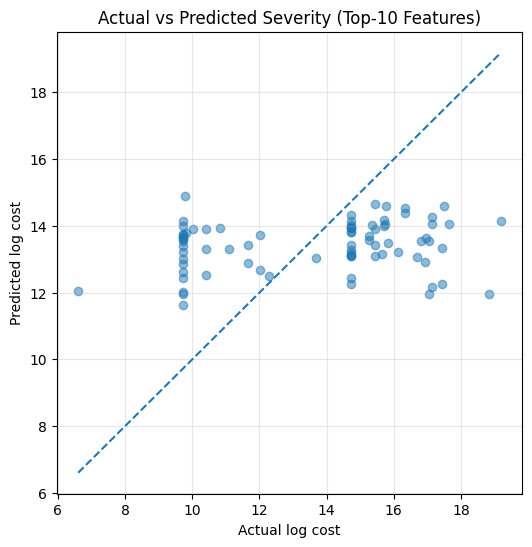

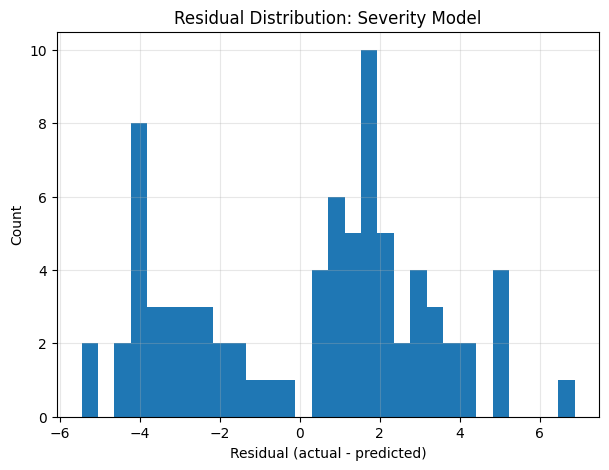

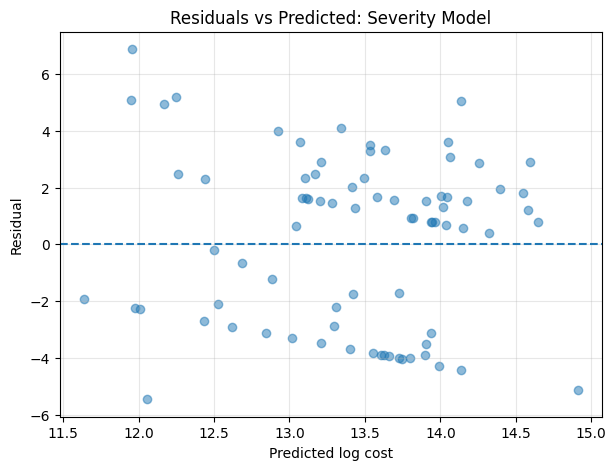

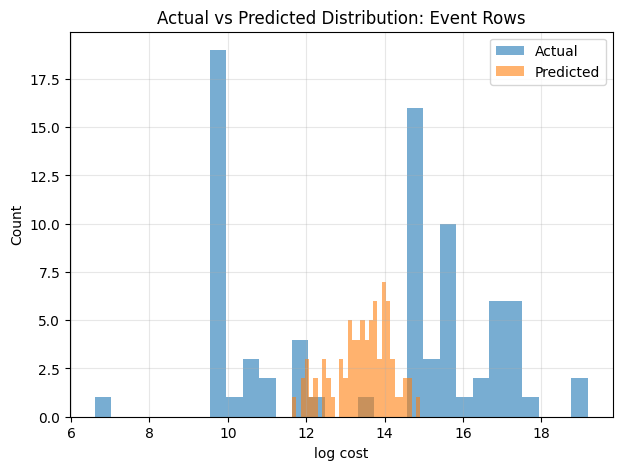

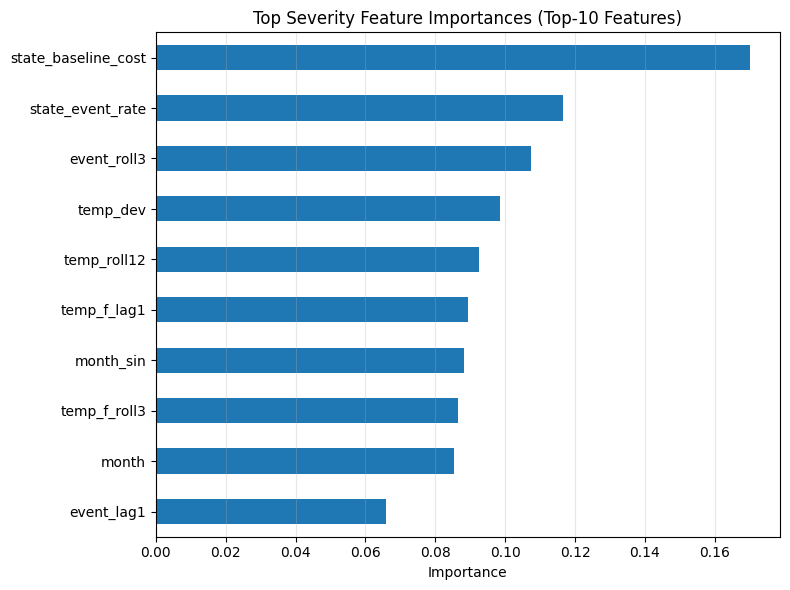


Top severity features:
state_baseline_cost    0.170139
state_event_rate       0.116401
event_roll3            0.107326
temp_dev               0.098415
temp_roll12            0.092386
temp_f_lag1            0.089289
month_sin              0.088272
temp_f_roll3           0.086407
month                  0.085349
event_lag1             0.066017
dtype: float32

===== Final comparison =====
Full classifier AUC: 0.9853339948997841
Full classifier AP: 0.8279490862012323
Top-10 classifier AUC: 0.9889456861636454
Top-10 classifier AP: 0.8575000386912609
Severity R2 (top-10 features): 0.03112691850803384


In [5]:
# -----------------------------
# 2nd stage: severity model on event rows only using top 10 features
# -----------------------------
y_train_reg = train_df[target]
y_test_reg = test_df[target]

train_events_only = train_df[train_df["event_flag"] == 1].copy()
test_events_only = test_df[test_df["event_flag"] == 1].copy()

X_train_reg = train_events_only[top_features]
y_train_reg_events = train_events_only[target]

X_test_reg = test_events_only[top_features]
y_test_reg_events = test_events_only[target]

reg = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    device="cuda",
    random_state=123
)

reg_param_grid = {
    "n_estimators": [300, 500, 800, 1000],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.1, 1.0],
    "reg_lambda": [1, 5, 10]
}

tscv_reg = TimeSeriesSplit(n_splits=6)

reg_search = RandomizedSearchCV(
    estimator=reg,
    param_distributions=reg_param_grid,
    n_iter=30,
    scoring="r2",
    cv=tscv_reg,
    verbose=1,
    n_jobs=1,
    random_state=123,
    error_score="raise"
)

reg_search.fit(X_train_reg, y_train_reg_events)
best_reg = reg_search.best_estimator_

event_only_preds = best_reg.predict(X_test_reg)
event_only_preds = np.clip(event_only_preds, 0, None)

event_only_r2 = r2_score(y_test_reg_events, event_only_preds)
event_only_rmse = np.sqrt(mean_squared_error(y_test_reg_events, event_only_preds))
event_only_mae = mean_absolute_error(y_test_reg_events, event_only_preds)

event_mean_pred = np.repeat(y_train_reg_events.mean(), len(y_test_reg_events))
event_zero_pred = np.zeros(len(y_test_reg_events))

print("\n===== 2nd Stage: Severity on Event Rows Only (Top-10 Features) =====")
print("Best regressor params:")
print(reg_search.best_params_)

print("\nEvent-only baseline comparison")
print("Mean predictor R2:", r2_score(y_test_reg_events, event_mean_pred))
print("Zero predictor R2:", r2_score(y_test_reg_events, event_zero_pred))
print("Event-only model R2:", event_only_r2)

print("\nEvent-only metrics")
print("RMSE:", event_only_rmse)
print("MAE:", event_only_mae)
print("R2:", event_only_r2)

pearson_corr = pearsonr(y_test_reg_events, event_only_preds)[0]
spearman_corr = spearmanr(y_test_reg_events, event_only_preds)[0]
residuals = y_test_reg_events - event_only_preds

print("\n===== Additional Severity Diagnostics =====")
print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)
print("Residual mean:", residuals.mean())
print("Residual std:", residuals.std())
print("Prediction std:", np.std(event_only_preds))
print("Actual std:", np.std(y_test_reg_events))
print("Train event rows:", len(train_events_only))
print("Test event rows:", len(test_events_only))

plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg_events, event_only_preds, alpha=0.5)
mn = min(y_test_reg_events.min(), event_only_preds.min())
mx = max(y_test_reg_events.max(), event_only_preds.max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("Actual log cost")
plt.ylabel("Predicted log cost")
plt.title("Actual vs Predicted Severity (Top-10 Features)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(residuals, bins=30)
plt.xlabel("Residual (actual - predicted)")
plt.ylabel("Count")
plt.title("Residual Distribution: Severity Model")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(event_only_preds, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted log cost")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted: Severity Model")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(y_test_reg_events, bins=30, alpha=0.6, label="Actual")
plt.hist(event_only_preds, bins=30, alpha=0.6, label="Predicted")
plt.xlabel("log cost")
plt.ylabel("Count")
plt.title("Actual vs Predicted Distribution: Event Rows")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

reg_importances = pd.Series(best_reg.feature_importances_, index=top_features).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
reg_importances.head(10).sort_values().plot(kind="barh")
plt.title("Top Severity Feature Importances (Top-10 Features)")
plt.xlabel("Importance")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop severity features:")
print(reg_importances)

print("\n===== Final comparison =====")
print("Full classifier AUC:", full_auc)
print("Full classifier AP:", full_ap)
print("Top-10 classifier AUC:", top10_auc)
print("Top-10 classifier AP:", top10_ap)
print("Severity R2 (top-10 features):", event_only_r2)


In [5]:
print("Feature columns used in model:")
for col in feature_cols:
    print(col)

Feature columns used in model:
month
temp_f
pcpn_in
temp_anom
pcpn_anom
temp_f_lag1
pcpn_in_lag1
temp_f_roll3
pcpn_in_roll3
month_sin
month_cos
temp_roll12
pcpn_roll12
temp_dev
pcpn_dev
temp_x_pcpn
temp_dev_x_pcpn_dev
event_lag1
event_roll3
temp_anom_x_pcpn_anom
state_baseline_cost
state_event_rate


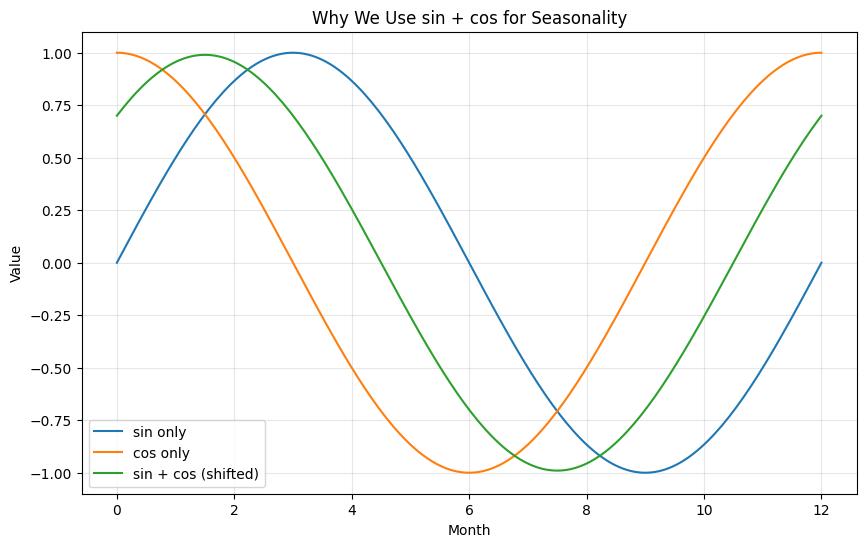

In [6]:
# Create "months" as continuous for smooth curve
x = np.linspace(0, 12, 200)

# Convert to angle
theta = 2 * np.pi * x / 12

# Components
sin_wave = np.sin(theta)
cos_wave = np.cos(theta)

# Combine with different weights (this creates phase shifts)
combo1 = 1.0 * sin_wave + 0.0 * cos_wave
combo2 = 0.7 * sin_wave + 0.7 * cos_wave
combo3 = 0.0 * sin_wave + 1.0 * cos_wave

plt.figure(figsize=(10,6))
plt.plot(x, sin_wave, label="sin only")
plt.plot(x, cos_wave, label="cos only")
plt.plot(x, combo2, label="sin + cos (shifted)")
plt.xlabel("Month")
plt.ylabel("Value")
plt.title("Why We Use sin + cos for Seasonality")
plt.legend()
plt.grid(alpha=0.3)
plt.show()